In [1]:
#data: salaery data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df=pd.read_csv('Salary_Data.csv')

In [11]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


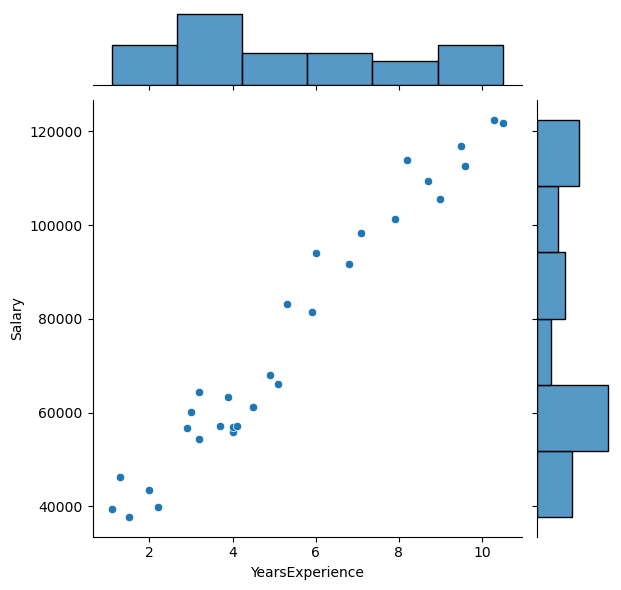

In [17]:
sns.jointplot(x='YearsExperience',y='Salary',data=df)

In [78]:
#seperate the data =input and output
#years as input, salary as op

x=df[['YearsExperience']]
y=df['Salary']

In [80]:
x

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [82]:
##as we dont knwo how our model with perform on unknown data, we use cross validation
#splitting done randomly by system

## Cross validation


In [85]:
from sklearn.model_selection import train_test_split

In [87]:
x_train,x_test,y_train,y_test =train_test_split(x,y,random_state=0,test_size=0.25) ##order should be maintained
#x_train =train input
#y_train= train input and respectively

In [89]:
x_train.shape

(22, 1)

In [91]:
df.shape

(30, 2)

In [93]:
x_test.shape

(8, 1)

## TRAIN THE MODEL

In [96]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()

In [98]:
regressor.fit(x_train,y_train)

LinearRegression()

## EVALUATE

In [101]:
y_pred=regressor.predict(x_test)

In [103]:
y_pred

array([ 41056.25705466, 123597.70938378,  65443.50433372,  63567.56223533,
       116093.94099022, 108590.17259667, 117031.91203942,  64505.53328452])

In [105]:
## create a df for comparing predict vs real
result=pd.DataFrame({'actual': y_test,'predicted':y_pred})

In [107]:
result

,actual,predicted
2,37731.0,41056.257055
28,122391.0,123597.709384
13,57081.0,65443.504334
10,63218.0,63567.562235
26,116969.0,116093.940990
24,109431.0,108590.172597
27,112635.0,117031.912039
11,55794.0,64505.533285


In [109]:
#various matrix can be used to check evlutaion


In [111]:
result.describe()

,actual,predicted
count,8.000000,8.000000
mean,84406.250000,87485.823990
std,34056.938453,32032.579447
min,37731.000000,41056.257055
25%,56759.250000,64271.040522
50%,86324.500000,87016.838465
75%,113718.500000,116328.433753
max,122391.000000,123597.709384


In [113]:
result.sum()

actual       675250.000000
predicted    699886.591918
dtype: float64

In [121]:
sum(abs((y_test-y_pred) /len(y_pred)))
#on avg this amount of error

3508.5455930660555

In [125]:
#method 2
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_pred)

3508.5455930660555

## MSE (mean square error)

In [128]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)

22407940.143340684

In [130]:
#RMSE root mean squared error
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_test,y_pred)

4733.70258289858

In [134]:
# for actual accuracy // coef of determination ,,r2 score
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9779208335417602

In [136]:
regressor.score(x,y)

0.955975487542377

In [138]:
regressor.coef_,regressor.intercept_

(array([9379.71049195]), 26986.691316737248)

In [140]:
regressor.predict([[12]])

C:\Users\krish\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([139543.21722009])

In [142]:
import math
math.sqrt(mean_squared_error(y_test,y_pred))

4733.70258289858

In [150]:
y_Pred=regressor.predict(x)

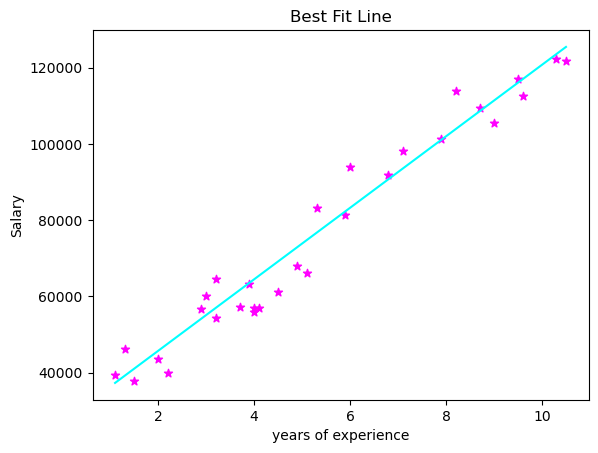

In [183]:
plt.title('Best Fit Line')
plt.xlabel('years of experience')
plt.ylabel('Salary')
plt.scatter(x,y,color='magenta',marker='*');
plt.plot(x,y_Pred,color='cyan');

## regplot

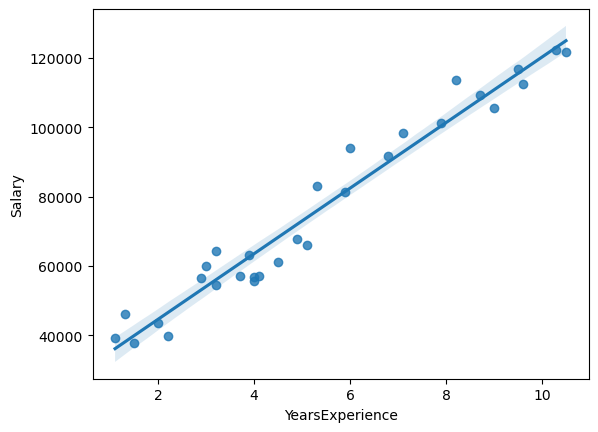

In [185]:
sns.regplot(x='YearsExperience',y='Salary',data=df);